In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

from gensim.models import Word2Vec

In [2]:
df = pd.read_csv("IMDB_Dataset.csv")

# Convert labels
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})


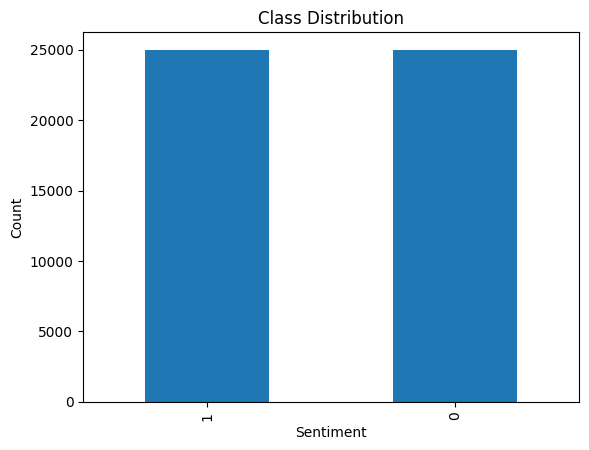

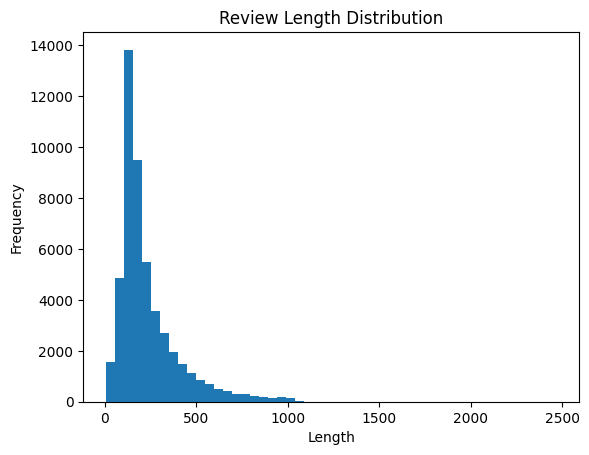

In [3]:
# Class distribution
plt.figure()
df["sentiment"].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Review length distribution
df["review_length"] = df["review"].apply(lambda x: len(x.split()))
plt.figure()
plt.hist(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    return text

df["clean_review"] = df["review"].apply(clean_text)

X = df["clean_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# ----------- (A) BAG OF WORDS -----------
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

# ----------- (B) TF-IDF -----------
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ----------- (C) WORD EMBEDDINGS (Word2Vec) -----------

# Tokenization
tokenized_train = [text.split() for text in X_train]

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,   # dimension of embeddings
    window=5,          # context window size
    min_count=2,       # ignore rare words
    workers=4
)

# Average Word2Vec
def get_avg_w2v(text, model, vector_size):
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_train_w2v = np.array([get_avg_w2v(text, w2v_model, 100) for text in X_train])
X_test_w2v = np.array([get_avg_w2v(text, w2v_model, 100) for text in X_test])

In [6]:
def train_and_evaluate(X_tr, X_te, name):
    model = LogisticRegression(max_iter=1000)  
    # max_iter: ensures convergence for large text data
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    print(f"\n{name} Results")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    
    return model

In [9]:
model_bow = train_and_evaluate(X_train_bow, X_test_bow, "BoW")
model_tfidf = train_and_evaluate(X_train_tfidf, X_test_tfidf, "TF-IDF")
model_w2v = train_and_evaluate(X_train_w2v, X_test_w2v, "Word2Vec")


BoW Results
Accuracy: 0.8787
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      4961
           1       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


TF-IDF Results
Accuracy: 0.8836
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.87      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


Word2Vec Results
Accuracy: 0.8413
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      4961
           1       0.84      0.85      0.84      5039

    accuracy                           0.84     10000
   macro avg       0.84      0

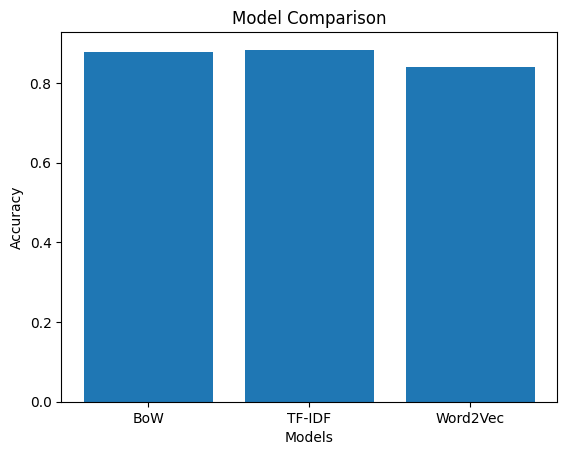

In [12]:
models = ["BoW", "TF-IDF", "Word2Vec"]
accuracies = [0.8787, 0.8836, 0.8413]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

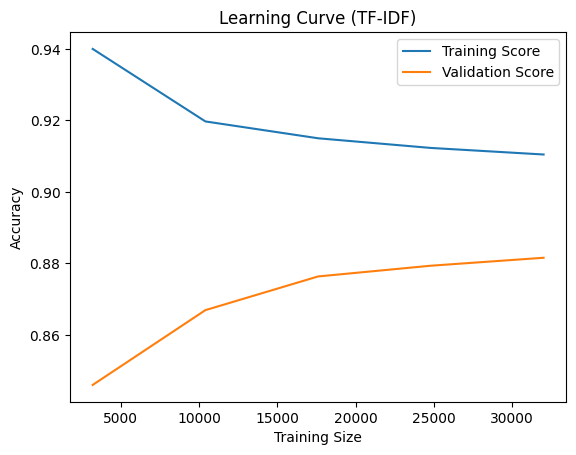

In [7]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    plt.figure()
    plt.plot(train_sizes, train_mean, label="Training Score")
    plt.plot(train_sizes, test_mean, label="Validation Score")
    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_learning_curve(LogisticRegression(max_iter=1000), X_train_tfidf, y_train, "Learning Curve (TF-IDF)")

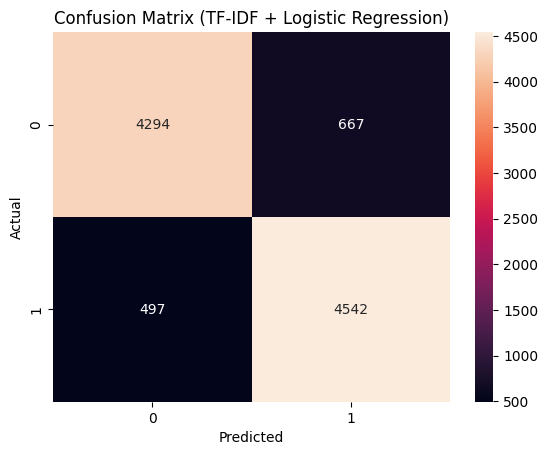

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model_tfidf.predict(X_test_tfidf))

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (TF-IDF + Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC-AUC Score: 0.9548348521524048


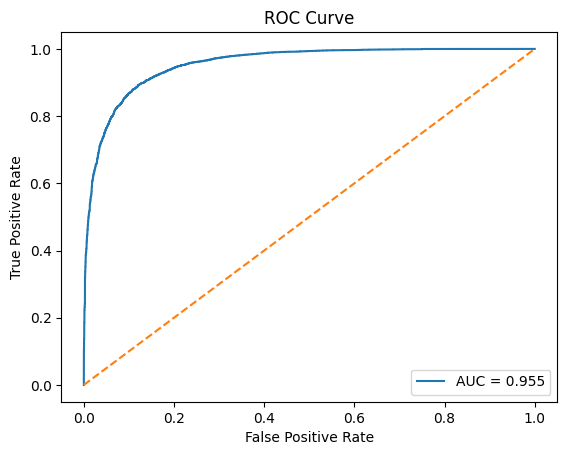

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilities
y_probs = model_tfidf.predict_proba(X_test_tfidf)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

print("ROC-AUC Score:", auc_score)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [10]:
feature_names = tfidf.get_feature_names_out()
coefficients = model_tfidf.coef_[0]

top_positive = np.argsort(coefficients)[-10:]
top_negative = np.argsort(coefficients)[:10]

print("\nTop Positive Words:", feature_names[top_positive])
print("\nTop Negative Words:", feature_names[top_negative])



Top Positive Words: ['hilarious' 'loved' 'brilliant' 'favorite' 'amazing' 'perfect'
 'wonderful' 'best' 'excellent' 'great']

Top Negative Words: ['worst' 'waste' 'awful' 'bad' 'boring' 'poor' 'terrible' 'poorly' 'dull'
 'worse']


In [11]:
import joblib
joblib.dump(model_tfidf, "final_sentiment_model.pkl")

['final_sentiment_model.pkl']